# YOLOv8 Detection & Segmentation
### DeepFashion2 – Top-5 Categories

**Prerequisite:** Run `preprocessing.ipynb` first.

**Classes (nc=6):**
- 0 → Background
- 1 → Short Sleeve Top
- 2 → Trousers
- 3 → Shorts
- 4 → Long Sleeve Top
- 5 → Skirt

Background handling: Each image gets an explicit background polygon covering the full image frame (class 0).

In [1]:
ls /kaggle/input/datasets/sasank93/vr-mini-project-pruned

pruned_test/  pruned_train/  pruned_val/


## 1. Setup & Installs

In [2]:
# Kaggle: no drive mount needed
import os
SAVE_DIR = "/kaggle/working/VR_Mini_Project-1"
os.makedirs(SAVE_DIR, exist_ok=True)
print("Save dir:", SAVE_DIR)

Save dir: /kaggle/working/VR_Mini_Project-1


In [3]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.7 MB/s eta 0:00:00


In [4]:
import os, json, shutil, random
import numpy as np
from PIL import Image
from tqdm import tqdm
import torch

# ---- Global constants (must match preprocessing) ----
TOP5           = [1, 8, 7, 2, 9]
# 0 = Background; clothing classes are 1-indexed so YOLO class 0 = Background
category_names = ['Background', 'Short Sleeve Top', 'Trousers', 'Shorts', 'Long Sleeve Top', 'Skirt']
fg_names       = category_names[1:]   # foreground-only names for display
NUM_CLASSES    = len(category_names)  # 6

# Map DeepFashion2 cat_id → YOLO class index (1-indexed; 0 reserved for background)
cat_to_idx     = {cat_id: i + 1 for i, cat_id in enumerate(TOP5)}
idx_to_name    = {i: name for i, name in enumerate(category_names)}

DRIVE_SAVE     = "/kaggle/working/VR_Mini_Project-1"
os.makedirs(DRIVE_SAVE, exist_ok=True)

print(f"NUM_CLASSES : {NUM_CLASSES}  (0=Background, 1-5=clothing)")
print("cat_to_idx  :", cat_to_idx)

NUM_CLASSES : 6  (0=Background, 1-5=clothing)
cat_to_idx  : {1: 1, 8: 2, 7: 3, 2: 4, 9: 5}


## 2. Build YOLO Dataset (images + polygon labels)

In [5]:
YOLO_ROOT = "/kaggle/working/yolo_dataset"
for split in ['train', 'val', 'test']:
    os.makedirs(f"{YOLO_ROOT}/{split}/images", exist_ok=True)
    os.makedirs(f"{YOLO_ROOT}/{split}/labels", exist_ok=True)


def process_yolo_split(filenames, src_img_dir, src_anno_dir,
                       dst_img_dir, dst_label_dir, cat_to_idx,
                       desc="Processing"):
    """Converts DeepFashion2 annotations to YOLO segmentation format.
    Class 0 = Background (explicit full-image rectangle polygon).
    Classes 1-5 = clothing items (1-indexed, normalised polygons).
    The background polygon is written first; clothing polygons follow.
    """
    skipped = 0
    for img_name in tqdm(filenames, desc=desc):
        img_path   = os.path.join(src_img_dir,  img_name)
        anno_path  = os.path.join(src_anno_dir,  img_name.replace('.jpg', '.json'))
        label_path = os.path.join(dst_label_dir, img_name.replace('.jpg', '.txt'))

        if not os.path.exists(anno_path):
            skipped += 1
            continue

        shutil.copy(img_path, os.path.join(dst_img_dir, img_name))

        with Image.open(img_path) as img:
            W, H = img.size

        with open(anno_path) as f:
            data = json.load(f)

        lines = []

        # ---- Class 0: Background — full image as a rectangle polygon ----
        # Four corners normalised: TL, TR, BR, BL
        lines.append("0 0.000000 0.000000 1.000000 0.000000 1.000000 1.000000 0.000000 1.000000")

        # ---- Classes 1-5: Clothing polygons ----
        for key in data:
            if not key.startswith("item"):
                continue
            cat_id = data[key]["category_id"]
            if cat_id not in cat_to_idx:
                continue

            yolo_cls = cat_to_idx[cat_id]   # 1-indexed
            polygons = data[key]["segmentation"]

            for poly in polygons:
                if len(poly) < 6:           # need at least 3 points
                    continue
                norm = []
                for i, coord in enumerate(poly):
                    if i % 2 == 0:          # X
                        norm.append(f"{max(0.0, min(1.0, coord / W)):.6f}")
                    else:                   # Y
                        norm.append(f"{max(0.0, min(1.0, coord / H)):.6f}")
                lines.append(f"{yolo_cls} " + " ".join(norm))

        with open(label_path, 'w') as f:
            f.write("\n".join(lines))

    print(f"  Skipped (missing annotation): {skipped}")


# ---- Collect file lists ----
# For train we replicate the 50 % subset used in classification
# (re-derive it here with the same seed so it matches)
all_train = sorted([f for f in os.listdir("/kaggle/input/datasets/sasank93/vr-mini-project-pruned/pruned_train/images") if f.endswith('.jpg')])
np.random.seed(42)
idx50 = np.random.choice(len(all_train), int(len(all_train) * 0.5), replace=False)
train_files = [all_train[i] for i in idx50]

val_files  = sorted([f for f in os.listdir("/kaggle/input/datasets/sasank93/vr-mini-project-pruned/pruned_val/images")  if f.endswith('.jpg')])
test_files = sorted([f for f in os.listdir("/kaggle/input/datasets/sasank93/vr-mini-project-pruned/pruned_test/images") if f.endswith('.jpg')])

print(f"Train: {len(train_files)} | Val: {len(val_files)} | Test: {len(test_files)}")

process_yolo_split(train_files, "/kaggle/input/datasets/sasank93/vr-mini-project-pruned/pruned_train/images", "/kaggle/input/datasets/sasank93/vr-mini-project-pruned/pruned_train/annos",
                   f"{YOLO_ROOT}/train/images", f"{YOLO_ROOT}/train/labels",
                   cat_to_idx, desc="Train")

process_yolo_split(val_files,   "/kaggle/input/datasets/sasank93/vr-mini-project-pruned/pruned_val/images",   "/kaggle/input/datasets/sasank93/vr-mini-project-pruned/pruned_val/annos",
                   f"{YOLO_ROOT}/val/images",   f"{YOLO_ROOT}/val/labels",
                   cat_to_idx, desc="Val")

process_yolo_split(test_files,  "/kaggle/input/datasets/sasank93/vr-mini-project-pruned/pruned_test/images",  "/kaggle/input/datasets/sasank93/vr-mini-project-pruned/pruned_test/annos",
                   f"{YOLO_ROOT}/test/images",  f"{YOLO_ROOT}/test/labels",
                   cat_to_idx, desc="Test")

print("\nDataset construction complete.")

Train: 61273 | Val: 23741 | Test: 21627


Train: 100%|██████████| 61273/61273 [31:18<00:00, 32.62it/s]


  Skipped (missing annotation): 0


Val: 100%|██████████| 23741/23741 [08:43<00:00, 45.31it/s]


  Skipped (missing annotation): 0


Test: 100%|██████████| 21627/21627 [09:01<00:00, 39.92it/s]

  Skipped (missing annotation): 0

Dataset construction complete.


In [6]:
# Write data.yaml — nc=6 (0=Background, 1-5=clothing)
yaml_content = f"""path: {YOLO_ROOT}
train: train/images
val:   val/images
test:  test/images

nc: {NUM_CLASSES}
names:
  0: Background
  1: {category_names[1]}
  2: {category_names[2]}
  3: {category_names[3]}
  4: {category_names[4]}
  5: {category_names[5]}
"""

yaml_path = f"{YOLO_ROOT}/data.yaml"
with open(yaml_path, 'w') as f:
    f.write(yaml_content)
print("data.yaml written:")
print(yaml_content)

data.yaml written:
path: /kaggle/working/yolo_dataset
train: train/images
val:   val/images
test:  test/images

nc: 6
names:
  0: Background
  1: Short Sleeve Top
  2: Trousers
  3: Shorts
  4: Long Sleeve Top
  5: Skirt



## 3. Training — YOLOv8n-seg (From Scratch)

In [7]:
from ultralytics import YOLO

# ---- Training from scratch: pretrained=False ----
model_scratch = YOLO("yolov8n-seg.yaml")   # architecture only, random weights

print("Starting YOLOv8n-seg TRAINING FROM SCRATCH...")
results_scratch = model_scratch.train(
    data=yaml_path,
    epochs=15,
    imgsz=640,
    batch=32,
    device=[0,1], 
    optimizer='AdamW',
    lr0=1e-3,
    weight_decay=5e-4,
    mosaic=1.0,
    degrees=10.0,
    flipud=0.0,
    fliplr=0.5,
    project=DRIVE_SAVE,
    name="yolo_scratch",
    pretrained=False
)
print("Scratch training done.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Starting YOLOv8n-seg TRAINING FROM SCRATCH...
Ultralytics 8.4.30 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/yolo_dataset/data.yaml, degrees=10.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=

## 4. Training — YOLOv8n-seg (Transfer Learning)

In [8]:
from ultralytics import YOLO

# ---- Transfer learning: starts from COCO pretrained weights ----
model_transfer = YOLO("yolov8n-seg.pt")   # pretrained on COCO

print("Starting YOLOv8n-seg TRANSFER LEARNING...")
results_transfer = model_transfer.train(
    data=yaml_path,
    epochs=15,
    imgsz=640,
    batch=32,
    device=[0,1],
    optimizer='AdamW',
    lr0=1e-4,              # lower LR for fine-tuning
    weight_decay=5e-4,
    mosaic=1.0,
    fliplr=0.5,
    project=DRIVE_SAVE,
    name="yolo_transfer"
)
print("Transfer learning done.")

Starting YOLOv8n-seg TRANSFER LEARNING...
New https://pypi.org/project/ultralytics/8.4.31 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.30 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.

## 5. Evaluation on Test Set

In [9]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import numpy as np

# ---- Point to best weights — change path to scratch if needed ----
BEST_WEIGHTS = f"{DRIVE_SAVE}/yolo_transfer/weights/best.pt"

best_model = YOLO(BEST_WEIGHTS)

print("\n=== YOLO EVALUATION ON TEST SET ===")
test_metrics = best_model.val(
    data=yaml_path,
    split='test',
    device=0,
    verbose=True
)


=== YOLO EVALUATION ON TEST SET ===
Ultralytics 8.4.30 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-seg summary (fused): 86 layers, 3,259,234 parameters, 0 gradients, 11.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 26.6±17.2 MB/s, size: 75.9 KB)
val: Scanning /kaggle/working/yolo_dataset/test/labels... 21627 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 21627/21627 744.2it/s 29.1s
val: /kaggle/working/yolo_dataset/test/images/000115.jpg: 2 duplicate labels removed
val: /kaggle/working/yolo_dataset/test/images/000744.jpg: 1 duplicate labels removed
val: /kaggle/working/yolo_dataset/test/images/001652.jpg: 1 duplicate labels removed
val: /kaggle/working/yolo_dataset/test/images/001998.jpg: 1 duplicate labels removed
val: /kaggle/working/yolo_dataset/test/images/002603.jpg: 1 duplicate labels removed
val: /kaggle/working/yolo_dataset/test/images/003177.jpg: 1 duplicate labels removed
val: /kaggle/working/yolo_dataset/test/images/003188.jpg: 

In [10]:
# ===================================================
# 5a. Detection metrics: mAP@[0.5:0.95], F1, AUC
# ===================================================
print("\n" + "="*60)
print("DETECTION METRICS (Bounding Box)")
print("="*60)

box = test_metrics.box
seg = test_metrics.seg

print(f"mAP@0.50       : {box.map50:.4f}")
print(f"mAP@[0.5:0.95] : {box.map:.4f}")
print(f"Mean Precision : {box.mp:.4f}")
print(f"Mean Recall    : {box.mr:.4f}")

print("\nPer-class AP@0.50:")
for i, name in enumerate(category_names):
    try:
        ap50 = box.ap50[i]
    except Exception:
        ap50 = float('nan')
    print(f"  {name:<20}: {ap50:.4f}")

print("\n" + "="*60)
print("SEGMENTATION METRICS (Mask)")
print("="*60)
print(f"Mask mAP@0.50       : {seg.map50:.4f}")
print(f"Mask mAP@[0.5:0.95] : {seg.map:.4f}")
print(f"Mask Mean Precision : {seg.mp:.4f}")
print(f"Mask Mean Recall    : {seg.mr:.4f}")

# Dice coefficient = F1 of mask predictions
mask_f1 = test_metrics.seg.f1  # shape: (num_thresholds,)
print(f"\nMax Dice Coefficient (Mask F1): {mask_f1.max():.4f}")
print(f"Dice @ 0.5 conf threshold    : {mask_f1[mask_f1.shape[0]//2]:.4f}")


DETECTION METRICS (Bounding Box)
mAP@0.50       : 0.8876
mAP@[0.5:0.95] : 0.7300
Mean Precision : 0.8470
Mean Recall    : 0.8407

Per-class AP@0.50:
  Background          : 0.9950
  Short Sleeve Top    : 0.8831
  Trousers            : 0.9124
  Shorts              : 0.9168
  Long Sleeve Top     : 0.7252
  Skirt               : 0.8933

SEGMENTATION METRICS (Mask)
Mask mAP@0.50       : 0.6714
Mask mAP@[0.5:0.95] : 0.4769
Mask Mean Precision : 0.7237
Mask Mean Recall    : 0.7171

Max Dice Coefficient (Mask F1): 0.9857
Dice @ 0.5 conf threshold    : 0.5503


In [11]:
# ===================================================
# 5b. mIoU on Segmentation Masks
# ===================================================
# YOLO val() returns mask mAP but not mIoU directly.
# We compute it manually by running inference on each test image
# and comparing predicted masks vs ground-truth polygon masks.

import cv2
from sklearn.metrics import jaccard_score

def polygon_to_mask(polygons, H, W):
    """Convert list-of-polygon coordinates to a binary mask (H x W)."""
    mask = np.zeros((H, W), dtype=np.uint8)
    for poly in polygons:
        pts = np.array(poly, dtype=np.float32).reshape(-1, 2).astype(np.int32)
        cv2.fillPoly(mask, [pts], 1)
    return mask


def compute_yolo_miou(model, test_img_dir, test_anno_dir,
                      cat_to_idx, category_names, conf_thresh=0.25):
    """Per-class IoU and Dice for YOLO mask predictions vs GT polygons.
    Skips class 0 (background) — only reports foreground classes 1-5.
    """
    fg_names = category_names[1:]   # ['Short Sleeve Top', ...]
    n_cls    = len(fg_names)        # 5
    # Internal accumulators indexed 0..4 → map to YOLO class 1..5
    iou_sum  = np.zeros(n_cls)
    dice_sum = np.zeros(n_cls)
    counts   = np.zeros(n_cls)

    test_imgs = sorted([f for f in os.listdir(test_img_dir) if f.endswith('.jpg')])

    for img_name in tqdm(test_imgs, desc="Computing mIoU"):
        img_path  = os.path.join(test_img_dir,  img_name)
        anno_path = os.path.join(test_anno_dir, img_name.replace('.jpg', '.json'))

        with Image.open(img_path) as img:
            W, H = img.size

        # Ground-truth masks per YOLO class (1-indexed)
        gt_polys = {c: [] for c in range(1, n_cls + 1)}
        if os.path.exists(anno_path):
            with open(anno_path) as f:
                data = json.load(f)
            for key in data:
                if not key.startswith('item'): continue
                cat_id = data[key]['category_id']
                if cat_id not in cat_to_idx: continue
                cls = cat_to_idx[cat_id]   # 1-indexed
                gt_polys[cls].extend(data[key]['segmentation'])

        # YOLO prediction
        res = model(img_path, verbose=False, conf=conf_thresh)[0]

        # Predicted masks per YOLO class (1-indexed)
        pred_masks_cls = {c: np.zeros((H, W), dtype=np.uint8) for c in range(1, n_cls + 1)}

        if res.masks is not None:
            for seg_mask, cls_tensor in zip(res.masks.data, res.boxes.cls):
                cls = int(cls_tensor.item())
                if cls == 0 or cls > n_cls: continue   # skip background predictions
                m = seg_mask.cpu().numpy()
                m = cv2.resize(m, (W, H))
                pred_masks_cls[cls] = np.maximum(pred_masks_cls[cls], (m > 0.5).astype(np.uint8))

        for c in range(1, n_cls + 1):
            ci = c - 1   # accumulator index 0..4
            gt_mask   = polygon_to_mask(gt_polys[c], H, W)
            pred_mask = pred_masks_cls[c]

            if gt_mask.sum() == 0 and pred_mask.sum() == 0:
                continue

            counts[ci] += 1
            intersection = (gt_mask & pred_mask).sum()
            union        = (gt_mask | pred_mask).sum()
            iou  = intersection / (union + 1e-7)
            dice = 2 * intersection / (gt_mask.sum() + pred_mask.sum() + 1e-7)
            iou_sum[ci]  += iou
            dice_sum[ci] += dice

    print("\n" + "="*60)
    print("SEGMENTATION: PER-CLASS mIoU & Dice (Foreground only)")
    print("="*60)
    valid_iou, valid_dice = [], []
    for ci, name in enumerate(fg_names):
        if counts[ci] > 0:
            iou_c  = iou_sum[ci]  / counts[ci]
            dice_c = dice_sum[ci] / counts[ci]
            valid_iou.append(iou_c);  valid_dice.append(dice_c)
            print(f"  {name:<20}: IoU={iou_c:.4f}  Dice={dice_c:.4f}  (n={int(counts[ci])})")
        else:
            print(f"  {name:<20}: IoU=N/A  Dice=N/A  (no samples)")

    print("-"*60)
    print(f"  Macro mIoU : {np.mean(valid_iou):.4f}")
    print(f"  Macro Dice : {np.mean(valid_dice):.4f}")
    return np.mean(valid_iou), np.mean(valid_dice)


miou, dice = compute_yolo_miou(
    best_model,
    "/kaggle/input/datasets/sasank93/vr-mini-project-pruned/pruned_test/images",
    "/kaggle/input/datasets/sasank93/vr-mini-project-pruned/pruned_test/annos",
    cat_to_idx, category_names
)

Computing mIoU: 100%|██████████| 21627/21627 [15:33<00:00, 23.17it/s]


SEGMENTATION: PER-CLASS mIoU & Dice (Foreground only)
  Short Sleeve Top    : IoU=0.6466  Dice=0.6951  (n=13399)
  Trousers            : IoU=0.6507  Dice=0.7216  (n=9195)
  Shorts              : IoU=0.6367  Dice=0.6919  (n=6495)
  Long Sleeve Top     : IoU=0.5060  Dice=0.5626  (n=7360)
  Skirt               : IoU=0.6052  Dice=0.6477  (n=5701)
------------------------------------------------------------
  Macro mIoU : 0.6090
  Macro Dice : 0.6638


ROC inference: 100%|██████████| 21627/21627 [11:31<00:00, 31.27it/s]



DETECTION: Per-Class Precision / Recall / F1 / AUC (FG only)
  Short Sleeve Top    : P=0.7883  R=0.9618  F1=0.8664  AUC=0.9542
  Trousers            : P=0.8895  R=0.9459  F1=0.9168  AUC=0.9833
  Shorts              : P=0.8368  R=0.9163  F1=0.8747  AUC=0.9772
  Long Sleeve Top     : P=0.7111  R=0.8978  F1=0.7936  AUC=0.9544
  Skirt               : P=0.7865  R=0.8767  F1=0.8291  AUC=0.9479
------------------------------------------------------------
  Macro P=0.8024 R=0.9197 F1=0.8561
  Micro P=0.8045 R=0.9293 F1=0.8624
  Mean AUC=0.9634


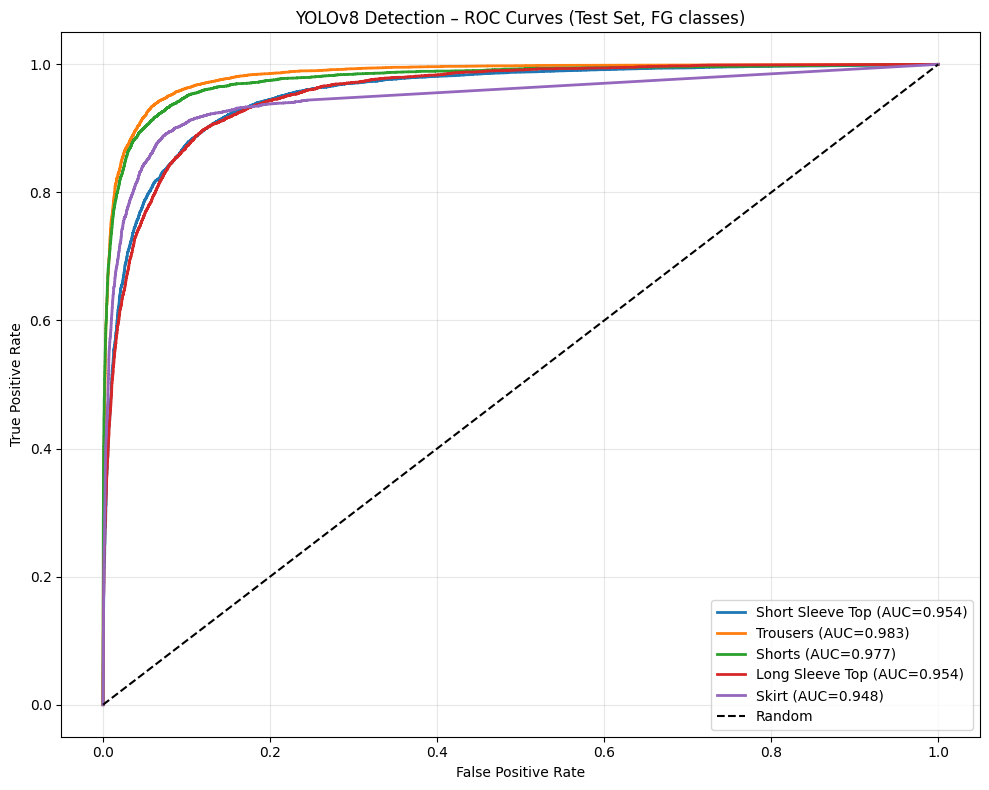

In [12]:
# ===================================================
# 5c. ROC Curves + AUC + F1 (Detection)
# ===================================================
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_fscore_support


def evaluate_yolo_detection(
        model, test_img_dir, test_anno_dir,
        cat_to_idx, category_names, conf_thresh=0.25):
    """
    Image-level ROC/AUC/F1 for detection — foreground classes only (1-5).
    For each image and each foreground class:
      - y_true : 1 if that class appears in GT, else 0
      - y_score: max predicted confidence YOLO assigned to that class
    Background (class 0) is excluded from these metrics.
    """
    fg_names = category_names[1:]    # 5 foreground names
    n_cls    = len(fg_names)         # 5
    # Keyed by YOLO class index 1..5
    y_true   = {c: [] for c in range(1, n_cls + 1)}
    y_scores = {c: [] for c in range(1, n_cls + 1)}
    y_pred   = {c: [] for c in range(1, n_cls + 1)}

    test_imgs = sorted([f for f in os.listdir(test_img_dir) if f.endswith('.jpg')])

    for img_name in tqdm(test_imgs, desc="ROC inference"):
        img_path  = os.path.join(test_img_dir,  img_name)
        anno_path = os.path.join(test_anno_dir, img_name.replace('.jpg', '.json'))

        gt_cls = set()
        if os.path.exists(anno_path):
            with open(anno_path) as f:
                data = json.load(f)
            for key in data:
                if not key.startswith('item'): continue
                cid = data[key]['category_id']
                if cid in cat_to_idx:
                    gt_cls.add(cat_to_idx[cid])   # 1-indexed

        res = model(img_path, verbose=False, conf=0.001)[0]

        pred_conf = {c: 0.0 for c in range(1, n_cls + 1)}
        if res.boxes is not None:
            for conf_t, cls_t in zip(res.boxes.conf, res.boxes.cls):
                c = int(cls_t.item())
                if 1 <= c <= n_cls:   # foreground only
                    pred_conf[c] = max(pred_conf[c], float(conf_t.item()))

        for c in range(1, n_cls + 1):
            y_true[c].append(1 if c in gt_cls else 0)
            y_scores[c].append(pred_conf[c])
            y_pred[c].append(1 if pred_conf[c] >= conf_thresh else 0)

    # ---- Print per-class F1 & AUC ----
    print("\n" + "="*60)
    print("DETECTION: Per-Class Precision / Recall / F1 / AUC (FG only)")
    print("="*60)
    all_aucs = []
    for c, name in zip(range(1, n_cls + 1), fg_names):
        yt = np.array(y_true[c])
        ys = np.array(y_scores[c])
        yp = np.array(y_pred[c])
        p, r, f1, _ = precision_recall_fscore_support(yt, yp, average='binary', zero_division=0)
        roc_auc = auc(*roc_curve(yt, ys)[:2]) if yt.sum() > 0 else float('nan')
        all_aucs.append(roc_auc)
        print(f"  {name:<20}: P={p:.4f}  R={r:.4f}  F1={f1:.4f}  AUC={roc_auc:.4f}")

    # ---- Macro / Micro averages ----
    yt_all = np.column_stack([y_true[c]  for c in range(1, n_cls + 1)])
    yp_all = np.column_stack([y_pred[c]  for c in range(1, n_cls + 1)])
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        yt_all, yp_all, average='macro',  zero_division=0)
    micro_p, micro_r, micro_f1, _ = precision_recall_fscore_support(
        yt_all, yp_all, average='micro',  zero_division=0)
    print("-"*60)
    print(f"  Macro P={macro_p:.4f} R={macro_r:.4f} F1={macro_f1:.4f}")
    print(f"  Micro P={micro_p:.4f} R={micro_r:.4f} F1={micro_f1:.4f}")
    print(f"  Mean AUC={np.nanmean(all_aucs):.4f}")

    # ---- ROC Curves ----
    plt.figure(figsize=(10, 8))
    for c, name in zip(range(1, n_cls + 1), fg_names):
        yt = np.array(y_true[c])
        ys = np.array(y_scores[c])
        if yt.sum() == 0: continue
        fpr, tpr, _ = roc_curve(yt, ys)
        plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC={all_aucs[c-1]:.3f})')
    plt.plot([0,1],[0,1],'k--', label='Random')
    plt.xlabel('False Positive Rate');  plt.ylabel('True Positive Rate')
    plt.title('YOLOv8 Detection – ROC Curves (Test Set, FG classes)')
    plt.legend(loc='lower right');  plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{DRIVE_SAVE}/yolo_roc_curves.png", dpi=150)
    plt.show()

evaluate_yolo_detection(
    best_model,
    "/kaggle/input/datasets/sasank93/vr-mini-project-pruned/pruned_test/images",
    "/kaggle/input/datasets/sasank93/vr-mini-project-pruned/pruned_test/annos",
    cat_to_idx, category_names
)

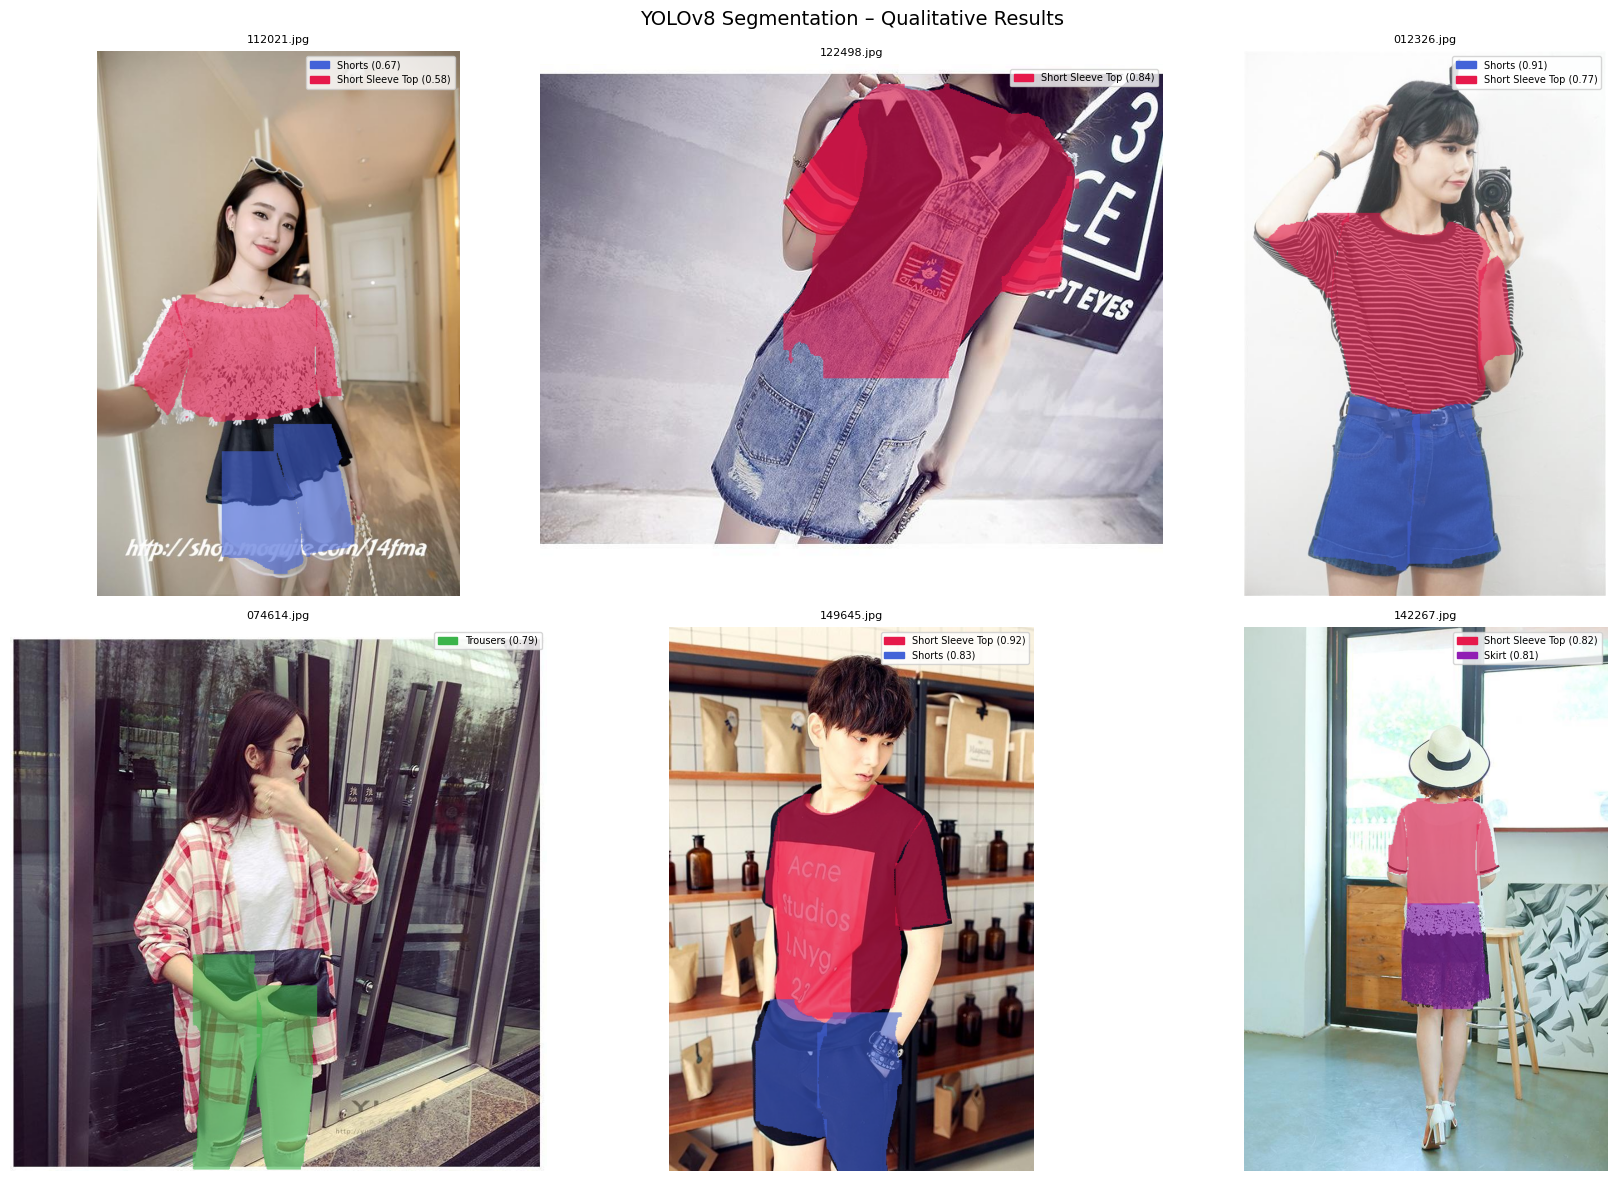

In [13]:
# ===================================================
# 5d. Qualitative Visualisation (sample predictions)
# ===================================================
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgba

# Index 0=grey(bg), 1-5=clothing colours
PALETTE = ['#888888', '#e6194b', '#3cb44b', '#4363d8', '#f58231', '#911eb4']

test_imgs = sorted([f for f in os.listdir("/kaggle/input/datasets/sasank93/vr-mini-project-pruned/pruned_test/images") if f.endswith('.jpg')])
random.seed(0)
sample_imgs = random.sample(test_imgs, min(6, len(test_imgs)))

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, img_name in zip(axes, sample_imgs):
    img_path = f"/kaggle/input/datasets/sasank93/vr-mini-project-pruned/pruned_test/images/{img_name}"
    res = best_model(img_path, verbose=False, conf=0.25)[0]

    orig = np.array(Image.open(img_path).convert('RGB'))
    overlay = orig.copy()
    H, W = orig.shape[:2]

    if res.masks is not None:
        for m, cls_t, conf_t in zip(res.masks.data, res.boxes.cls, res.boxes.conf):
            cls  = int(cls_t.item())
            if cls == 0: continue   # skip background overlay
            mask = cv2.resize(m.cpu().numpy(), (W, H)) > 0.5
            color = np.array(to_rgba(PALETTE[cls % len(PALETTE)])[:3]) * 255
            overlay[mask] = (overlay[mask] * 0.4 + color * 0.6).astype(np.uint8)

    ax.imshow(overlay)
    patches = []
    if res.boxes is not None:
        seen = set()
        for cls_t, conf_t in zip(res.boxes.cls, res.boxes.conf):
            cls = int(cls_t.item())
            if cls == 0 or cls in seen: continue   # skip background
            seen.add(cls)
            patches.append(mpatches.Patch(
                color=PALETTE[cls % len(PALETTE)],
                label=f"{idx_to_name.get(cls, str(cls))} ({float(conf_t):.2f})"))
    ax.legend(handles=patches, fontsize=7, loc='upper right')
    ax.set_title(img_name, fontsize=8)
    ax.axis('off')

plt.suptitle('YOLOv8 Segmentation – Qualitative Results', fontsize=14)
plt.tight_layout()
plt.savefig(f"{DRIVE_SAVE}/yolo_qualitative.png", dpi=150)
plt.show()